
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [1]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [2]:

# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.16



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [3]:
import nltk

# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# Download the 'punkt_tab' resource as suggested by the error
nltk.download('punkt_tab')

# Download the specific tagger resource for English
nltk.download('averaged_perceptron_tagger_eng')

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?

DT means determiner, which includes words like “the.” JJ means adjective, which describes a noun, like “quick” and “lazy.”

2. Why do you think 'brown' and 'lazy' have the same tag?

In my results, “brown” and “lazy” actually did not receive the same tag. “Brown” was tagged as NN (noun), while “lazy” was tagged as JJ (adjective). In this sentence, I would expect “brown” to be an adjective because it describes the fox. This shows that POS taggers can sometimes interpret a word differently than expected based on context.

3. Can you guess what 'VBZ' represents?

VBZ represents a third-person singular present-tense verb. In this sentence, “jumps” receives this tag because the singular subject “fox” is performing the action.

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [4]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?

I think SpaCy's tags are easier to understand because they use clear labels like ADJ, NOUN, VERB, and DET instead of abbreviations like JJ, NN, VBZ, and DT.

- Do you notice any differences in how they tag the same words?

The main difference I noticed was the word “brown.” NLTK tagged it as NN (noun), while SpaCy tagged it as ADJ (adjective). In this sentence, “brown” describes the fox, so SpaCy's tag makes more sense to me.

- Which system would you prefer for a beginner? Why?

I would prefer SpaCy for a beginner because the tag names are easier to recognize without having to memorize as many abbreviations. It makes the output easier to read and understand while learning POS tagging.


## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [5]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?

The computer uses the surrounding words and sentence structure to determine how “lead” is being used. For example, in “I will lead the team,” the word follows “will,” which helps indicate that it is a verb. In “The lead pipe,” it is being used as a noun.

2. What clues in the sentence help determine the correct part of speech?

Words around the ambiguous word provide clues, including determiners, helping verbs, and nearby nouns. The position of the word in the sentence also helps the tagger predict its grammatical role.

3. Can you think of other words that change meaning based on context?

Other words that can change based on context include “run,” “light,” and “watch.” For example, “I watch TV” uses “watch” as a verb, while “I bought a watch” uses it as a noun.

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [6]:

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags
penn_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence))
universal_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence), tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below

The Penn Treebank tag set is more detailed, while the Universal tag set is simpler. In my results, Penn Treebank used 8 different tags compared to 6 Universal tags. Penn Treebank also gives more specific information, such as NNS for a plural noun and VBD for a past-tense verb.

2. When might you want detailed tags vs. simple tags? Enter your answer below

Detailed tags would be useful when the exact grammatical form of a word matters, such as distinguishing between verb tenses or singular and plural nouns. Simpler tags would be useful when I only need the general role of a word and want the results to be easier to interpret.

3. If you were building a search engine, which would you choose? Why? Enter your answer below

If I were building a search engine, I would choose the Universal tag set because broad categories like NOUN, VERB, and ADJ would make it easier to identify the main meaning and structure of a search query without needing every grammatical detail.

---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [7]:

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# TODO: Process each messy text sample
# 1. Use both NLTK and SpaCy
# 2. Count how many words each tagger fails to recognize properly
# 3. Identify problematic words (slang, contractions, etc.)

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # TODO: SpaCy processing
    spacy_doc = nlp(text)

    # TODO: Find problematic words (tagged as 'X' or unknown)
    problematic_nltk = [word for word, tag in nltk_tags if tag == 'X']
    problematic_spacy = [token.text for token in spacy_doc if token.pos_ == 'X']

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # TODO: Calculate success rate
    nltk_success_rate = (len(nltk_tokens) - len(problematic_nltk)) / len(nltk_tokens)
    spacy_success_rate = (len(spacy_doc) - len(problematic_spacy)) / len(spacy_doc)

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy success rate: 100.0%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
----------------------------------------
NLTK problematic words: []
SpaCy problematic words: []
NLTK success rate: 100.0%
SpaCy suc


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?

Based on my results, both NLTK and SpaCy handled the informal language equally well according to the success-rate measurement. Both had a 100% success rate for all five samples and did not label any words as unknown. However, this only shows that they assigned tags to every token, not that every tag was necessarily accurate.

2. What types of words cause the most problems?

My results did not identify any words as problematic, but slang, abbreviations, contractions, stretched spellings, and emojis could still be challenging. Examples from the samples include “rn,” “smh,” “cuz,” “fr,” “idk,” “tbh,” “sooo,” and 😤.

3. How might you preprocess text to improve tagging accuracy?

I could preprocess the text by normalizing slang and abbreviations, correcting unusual spellings, handling contractions, and removing unnecessary symbols when appropriate. For example, “rn” could become “right now” and “idk” could become “I don't know.” Text preprocessing helps standardize noisy text before further processing.

4. What are the implications for real-world applications?


Real-world applications cannot assume that assigning a POS tag means the tag is correct. Informal language from social media, speech transcripts, and customer service conversations can be interpreted incorrectly even when the system recognizes every token. This could affect later tasks that depend on accurate linguistic analysis.


## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [8]:

# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# TODO: Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicators (nouns related to issues)

analysis_results = []

# Define urgent terms (e.g., words that indicate immediate action or high priority)
urgent_terms = {'immediately', 'asap', 'now', 'urgent', 'quickly', 'critical'}

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # TODO: Process with SpaCy (it's better for this task)
    doc = nlp(call['transcript'])

    # TODO: Extract different types of words
    emotional_adjectives = [
        token.text for token in doc
        if token.pos_ == 'ADJ'
    ]

    action_verbs = [
        token.text for token in doc
        if token.pos_ == 'VERB'
    ]
    problem_nouns = [
        token.text for token in doc
        if token.pos_ == 'NOUN'
    ]


    # TODO: Calculate sentiment indicators
    positive_words = {'love', 'great', 'good', 'helpful', 'excellent', 'happy'}
    negative_words = {
        'frustrated', 'ridiculous', 'unacceptable',
        'confused', 'issue', 'problem', 'crashes'
    }

    # These should be calculated before they are used in the 'result' dictionary
    positive_matches = [
        token.text for token in doc
        if token.lower_ in positive_words
    ]

    negative_matches = [
        token.text for token in doc
        if token.lower_ in negative_words
    ]

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_matches) - len(negative_matches),
        'urgency_indicators': sum(
            1 for token in doc if token.lower_ in urgent_terms
        )
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['locked', 'access', 'trying', 'works']
Problem nouns: ['account', 'files', 'hours']
Sentiment score: -2

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: ['small', 'mobile']
Action verbs: ['love', 'having', 'crashes', 'try', 'upload', 'help', 'fix']
Problem nouns: ['service', 'issue', 'app', 'photos']
Sentiment score: -1

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charged me twice this mo

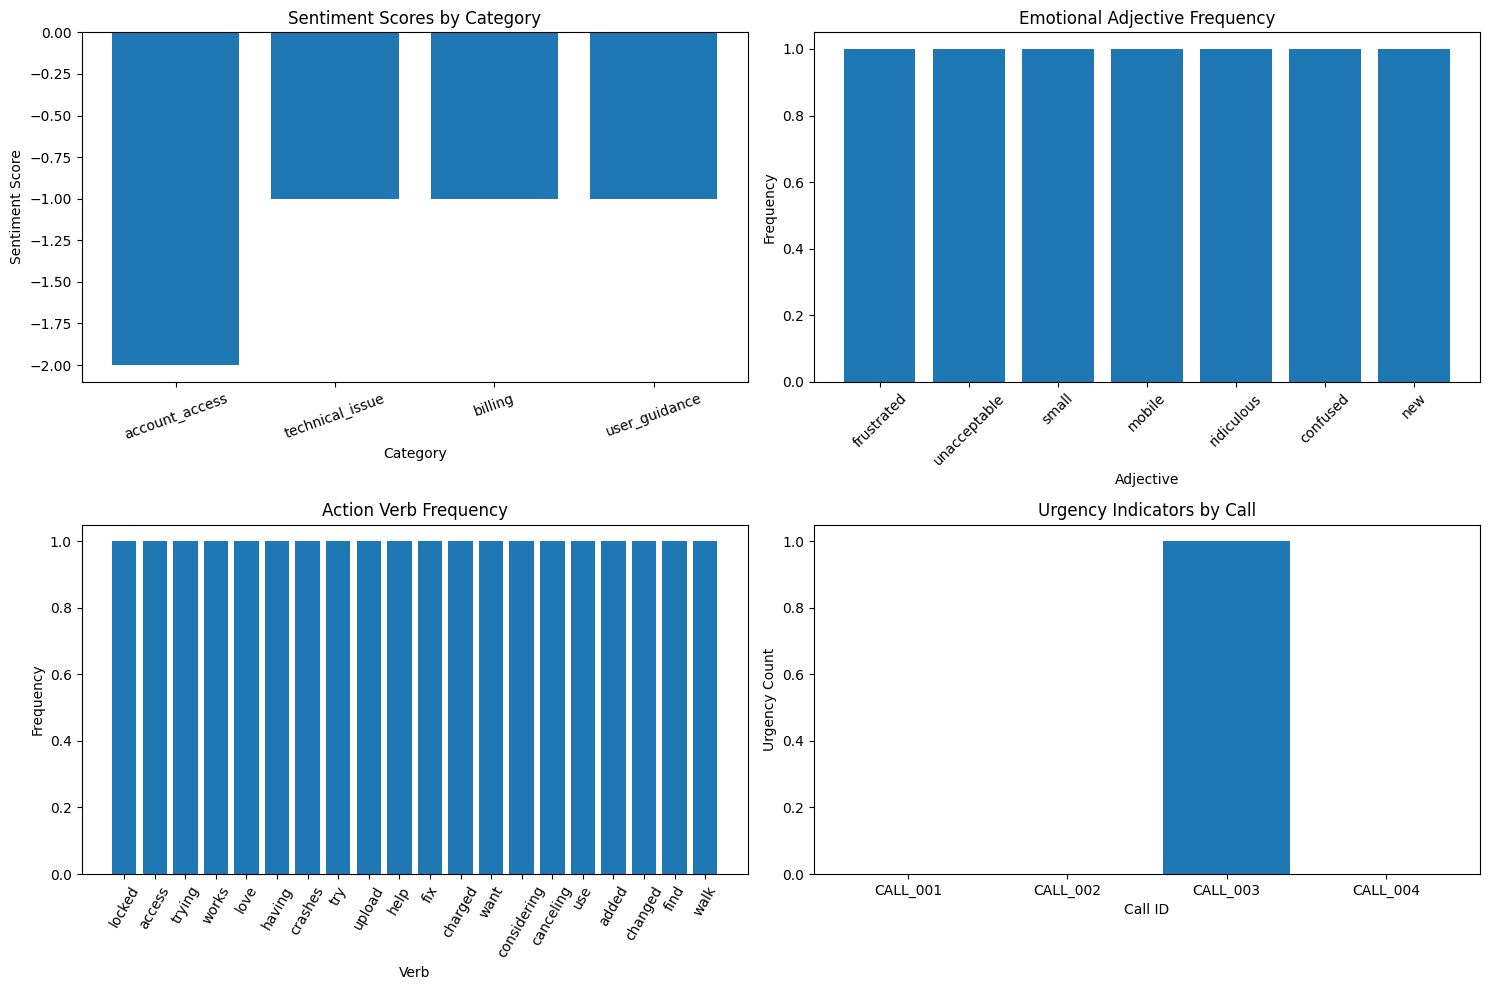

In [9]:

# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - Sentiment by category
axes[0, 0].bar(df['category'], df['sentiment_score'])
axes[0, 0].set_title('Sentiment Scores by Category')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Sentiment Score')
axes[0, 0].tick_params(axis='x', rotation=20)

# Plot 2 - Most common emotional adjectives
all_adjectives = [
    word
    for words in df['emotional_adjectives']
    for word in words
]
adjective_counts = Counter(all_adjectives)

axes[0, 1].bar(adjective_counts.keys(), adjective_counts.values())
axes[0, 1].set_title('Emotional Adjective Frequency')
axes[0, 1].set_xlabel('Adjective')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3 - Action verb frequency
all_verbs = [
    word
    for words in df['action_verbs']
    for word in words
]
verb_counts = Counter(all_verbs)

axes[1, 0].bar(verb_counts.keys(), verb_counts.values())
axes[1, 0].set_title('Action Verb Frequency')
axes[1, 0].set_xlabel('Verb')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].tick_params(axis='x', rotation=60)

# Plot 4 - Urgency analysis
axes[1, 1].bar(df['call_id'], df['urgency_indicators'])
axes[1, 1].set_title('Urgency Indicators by Call')
axes[1, 1].set_xlabel('Call ID')
axes[1, 1].set_ylabel('Urgency Count')

plt.tight_layout()
plt.show()



### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?

This analysis could help prioritize tickets by identifying negative emotional language and urgency indicators. For example, CALL_003 contained the word “immediately” and was the only call with an urgency score of 1, so it could be flagged for faster attention. Sentiment and urgency could be combined with the problem category to help determine which customers may need quicker assistance.

2. What patterns do you notice in different problem categories?

Each category contained different nouns and verbs related to the customer's issue. The account access call included words like “account,” “files,” “locked,” and “access,” while the billing call included “billing,” “refund,” “charged,” and “canceling.” The technical issue included “app,” “crashes,” “upload,” and “fix.” These patterns could help identify what type of problem the customer is experiencing.

3. How might you automate the routing of calls based on POS analysis?

A system could extract important nouns and verbs from each transcript and use them as features for routing. For example, words related to an account and accessing files could be routed to account support, while words related to billing, refunds, and charges could be routed to the billing department. Emotional and urgency indicators could also be used to flag calls that may need faster attention.

4. What are the limitations of this approach?

POS tags identify grammatical roles but do not fully explain the meaning or emotion behind a word. In my results, words like “small,” “mobile,” and “new” were identified as adjectives even though they were not emotional language. The problem noun list also included words like “hours” and “month” that did not describe the actual problem. The sentiment scores were also very similar, with CALL_001 receiving -2 and the other three calls receiving -1, even though their language and situations were different. This shows that POS tagging alone would not be enough for accurate sentiment analysis or customer service routing.


## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.0012s
NLTK Univ time: 0.0120s
SpaCy time: 0.0638s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0038s
NLTK Univ time: 0.0035s
SpaCy time: 0.0347s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0081s
NLTK Univ time: 0.0058s
SpaCy time: 0.0684s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that button thingy, it should totally work, right?
------------------------------

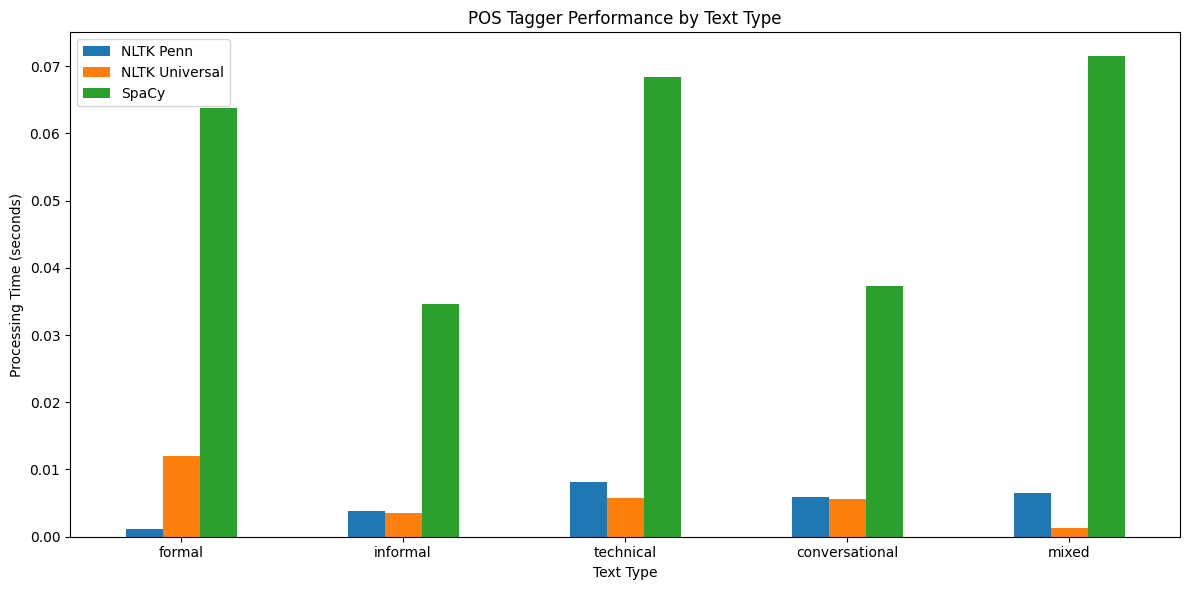

In [10]:

import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# TODO: Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(list)

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # TODO: NLTK Penn Treebank timing
    start_time = time.time()
    nltk_tokens = nltk.word_tokenize(text)
    nltk_penn_tags = nltk.pos_tag(nltk_tokens)
    nltk_penn_time = time.time() - start_time

    # TODO: NLTK Universal timing
    start_time = time.time()
    nltk_univ_tags = nltk.pos_tag(nltk_tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # TODO: SpaCy timing
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time

    # TODO: Count unknown/problematic tags
    nltk_unknown = sum(1 for word, tag in nltk_univ_tags if tag == 'X')
    spacy_unknown = sum(1 for token in spacy_doc if token.pos_ == 'X')

    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown': nltk_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown words: {nltk_unknown}")
    print(f"SpaCy unknown words: {spacy_unknown}")

# TODO: Create performance comparison visualization
benchmark_df = pd.DataFrame(benchmark_results).T

benchmark_df[
    ['nltk_penn_time', 'nltk_univ_time', 'spacy_time']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('POS Tagger Performance by Text Type')
plt.xlabel('Text Type')
plt.ylabel('Processing Time (seconds)')
plt.xticks(rotation=0)
plt.legend(['NLTK Penn', 'NLTK Universal', 'SpaCy'])
plt.tight_layout()
plt.show()



### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?

NLTK was the fastest overall in my benchmark, although the Penn Treebank and Universal versions varied depending on the type of text. Both were consistently faster than SpaCy in my final run. Speed would matter when processing a large number of texts, such as thousands of customer service transcripts, because small differences could add up at a larger scale.

2. Which handles informal text best?

Based on the unknown-word measurement, both NLTK and SpaCy handled the informal text well because neither produced any unknown words. However, this benchmark does not measure whether every POS tag was actually correct, so I cannot determine which was more accurate on informal language from these results alone.

3. How do the taggers compare on technical jargon?

Both taggers processed the technical sample without producing any unknown words, even with terms such as “API,” “JSON,” and “HTTP.” NLTK was faster on this sample, but the results do not show whether one tagger assigned more accurate POS tags to the technical terms.

4. What trade-offs do you see between speed and accuracy?

My benchmark clearly measured a speed difference, with NLTK being faster than SpaCy, but it did not directly measure accuracy. Counting unknown words only shows whether the taggers assigned an X or unknown category, not whether the assigned tag was correct. Because of that, I would need a manually labeled test set to make a true speed-versus-accuracy comparison.


## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [11]:

# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

# TODO: Process each edge case and analyze failures
for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # TODO: Process with both taggers
        nltk_tokens = nltk.word_tokenize(text)
        nltk_tags = nltk.pos_tag(nltk_tokens)
        spacy_doc = nlp(text)


        # TODO: Identify potential errors or weird tags
        # Look for: repeated tags, unusual patterns, X tags, etc.

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        # TODO: Analyze what went wrong
        nltk_unknown = [(w, t) for w, t in nltk_tags if t == 'X']
        spacy_unknown = [
            (token.text, token.pos_)
            for token in spacy_doc
            if token.pos_ == 'X'
        ]

        nltk_tag_counts = Counter(tag for word, tag in nltk_tags)
        spacy_tag_counts = Counter(token.pos_ for token in spacy_doc)

        print(f"NLTK unknown/X tags: {nltk_unknown}")
        print(f"SpaCy unknown/X tags: {spacy_unknown}")
        print(f"NLTK tag pattern: {dict(nltk_tag_counts)}")
        print(f"SpaCy tag pattern: {dict(spacy_tag_counts)}")

    except Exception as e:
        print(f"❌ Error processing: {e}")

# TODO: Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
print("Key limitations observed:")
print("- Ambiguous and repeated words can receive questionable POS tags.")
print("- NLTK and SpaCy can interpret the same words differently.")
print("- Social media content, especially emojis, can be difficult to classify.")
print("- Technical terms can receive unexpected POS tags.")
print("- A tagger assigning a tag does not necessarily mean the tag is correct.")


🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
NLTK unknown/X tags: []
SpaCy unknown/X tags: []
NLTK tag pattern: {'NNP': 3, 'NN': 5, '.': 1}
SpaCy tag pattern: {'PROPN': 7, 'NOUN': 1, 'PUNCT': 1}

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana', 'NN'), ('.', '.')]
SpaCy tags: [('Time', 


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

These edge cases are difficult because the taggers depend on context and common language patterns to determine a word's grammatical role. Repeated and ambiguous words do not provide enough normal context. For example, NLTK tagged every occurrence of "can" as MD, while SpaCy tagged most as AUX. Social media symbols, emojis, and newer technical terms also do not follow normal sentence patterns, which can lead to unusual tags.


2. How might you preprocess text to handle some of these issues?

I could preprocess the text by normalizing slang and unusual spellings, separating or identifying emojis, URLs, hashtags, and usernames, and expanding abbreviations when appropriate. For technical text, I could also identify domain-specific terms before POS tagging so they are not interpreted only from their spelling or position in the sentence. Text preprocessing helps standardize noisy text before further processing.


3. When would these limitations matter in real applications?

These limitations would matter when POS tags are used for tasks such as customer service routing, sentiment analysis, social media analysis, or processing technical support messages. An incorrect tag could cause the system to misunderstand an important word or action. This lab showed that a tagger can produce a tag for every word even when some of those tags are questionable, so simply having no unknown words does not guarantee accurate analysis.


4. How do modern large language models handle these cases differently?

Modern large language models can use broader context when interpreting ambiguous language instead of assigning a POS tag mainly from local grammatical patterns. This can help them recognize that the same word may have different meanings or grammatical roles depending on the sentence. However, unusual sentences, repeated words, slang, emojis, and specialized terminology can still be difficult, so they are not guaranteed to interpret every edge case correctly.

---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.


2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?


3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?


4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)


5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?




### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**

After using both tools, I would probably choose SpaCy for most real-world projects because I found its POS labels easier to understand and its output easier to work with. NLTK was much faster in my benchmark, so I can see why I would choose it for a simpler task or when processing speed is the priority. What surprised me was that neither tool was always right. For example, NLTK labeled "brown" as a noun while SpaCy recognized it as an adjective. This lab taught me that I would choose a tool based on the needs of the project instead of assuming one is always better.

**2. Real-World Applications:**

The customer service activity made POS tagging feel more useful to me because I could see how it could help sort actual support requests. I would use it to identify important nouns and actions in customer messages and combine that information with sentiment and urgency. For example, words related to billing, refunds, accounts, or apps could help determine where a request should go. I also learned that I would not rely on POS tagging alone because words like "hours" and "month" were identified as nouns even though they did not describe the actual problem.

**3. Limitations and Solutions:**

The biggest limitation I noticed was that a tagger can confidently give a word a tag and still be wrong. Before this lab, I think I would have assumed that no unknown words meant the text was handled successfully, but the edge cases showed that this is not true. Both taggers struggled with repeated words, ambiguity, emojis, and technical language even when they produced tags. I would work around this by preprocessing noisy text and using additional context, domain-specific rules, or custom training instead of trusting POS tags by themselves.

**4. Future Learning:**

I would like to explore custom training and domain adaptation more because the technical and social media examples made me wonder how much the results could improve if a model were trained specifically for that type of language. I am especially interested in seeing whether slang, emojis, abbreviations, and newer technical terms could be handled more accurately. I would also like to compare neural approaches with the methods we used in this lab to see how they handle the same difficult examples.

**5. Integration:**

This lab helped me understand that POS tagging makes more sense as one part of a larger NLP pipeline than as a final result by itself. Knowing whether something is a noun, verb, or adjective can help with tasks like sentiment analysis, information extraction, and identifying topics or actions, but the customer service exercise showed me that grammatical categories alone do not explain what a person actually means. I would use POS information together with other NLP techniques so that the system has more context before making a decision.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
